In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Environment ready.
Generated 200/1200
Generated 400/1200
Generated 600/1200
Generated 800/1200
Generated 1000/1200
Generated 1200/1200
Dataset generation done: ./sat_jam_kaggle/data


  0%|          | 0/1200 [00:00<?, ?it/s]/tmp/ipython-input-1038436365.py:126: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Sxx = signal.spectrogram(iq, fs=fs, nperseg=nperseg, noverlap=noverlap)
100%|██████████| 1200/1200 [00:01<00:00, 987.92it/s] 


Preprocessing complete. Spectrograms & features saved in: ./sat_jam_kaggle/processed
--- SVM ---
Accuracy: 0.8125
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        74
           1     0.8478    0.8667    0.8571        45
           2     0.6111    0.6111    0.6111        36
           3     0.6190    0.3611    0.4561        36
           4     0.7460    0.9592    0.8393        49

    accuracy                         0.8125       240
   macro avg     0.7648    0.7596    0.7527       240
weighted avg     0.8041    0.8125    0.8005       240

Confusion matrix:
[[74  0  0  0  0]
 [ 0 39  4  2  0]
 [ 0  7 22  5  2]
 [ 0  0  9 13 14]
 [ 0  0  1  1 47]]
--- RandomForest ---
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        74
           1     0.8000    0.8889    0.8421        45
           2     0.6429    0.5000    0.5625        36
           3     0.67

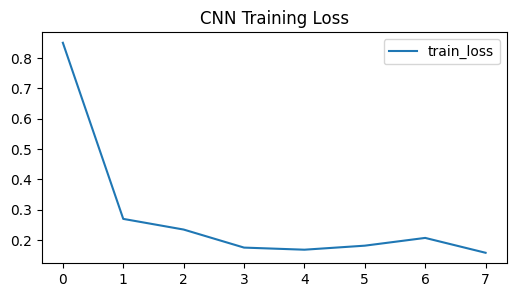

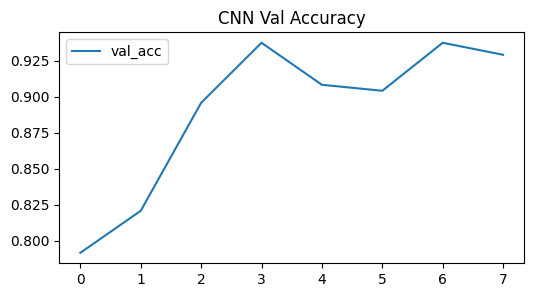

Epoch 1 - loss: 1.5875 - val_acc: 0.3250
Epoch 2 - loss: 1.4478 - val_acc: 0.5417
Epoch 3 - loss: 1.0900 - val_acc: 0.5833
Epoch 4 - loss: 0.9454 - val_acc: 0.7333
Epoch 5 - loss: 0.6926 - val_acc: 0.7542
Epoch 6 - loss: 0.6364 - val_acc: 0.7875
Epoch 7 - loss: 0.5820 - val_acc: 0.7625
Epoch 8 - loss: 0.5138 - val_acc: 0.8375


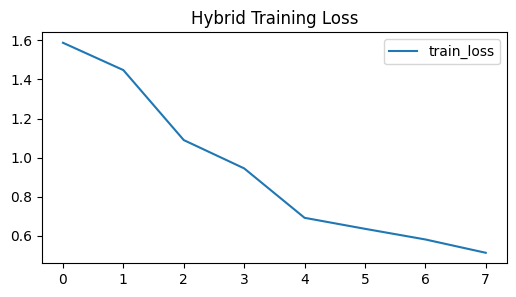

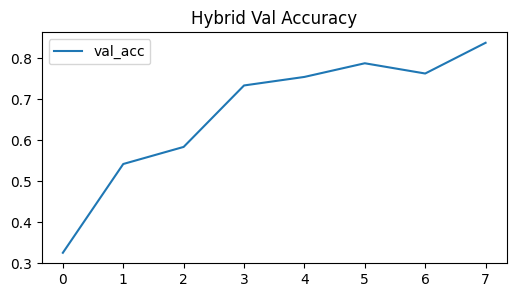

RandomForest Results
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        74
           1       0.80      0.89      0.84        45
           2       0.64      0.50      0.56        36
           3       0.68      0.64      0.66        36
           4       0.83      0.92      0.87        49

    accuracy                           0.83       240
   macro avg       0.79      0.79      0.79       240
weighted avg       0.83      0.83      0.83       240

CNN Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       0.84      0.92      0.88        53
           2       1.00      1.00      1.00        29
           3       0.89      0.78      0.83        40
           4       1.00      1.00      1.00        51

    accuracy                           0.95       240
   macro avg       0.95      0.94      0.94       240
weighted av

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


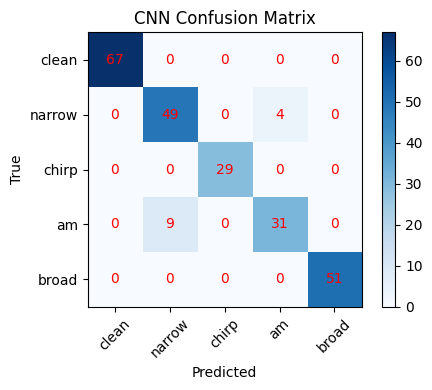

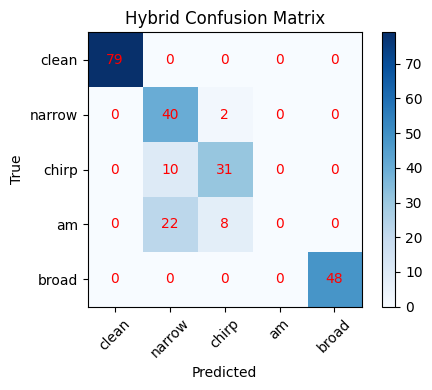

Saved final models in ./sat_jam_kaggle/models
Done. You can download the models from the notebook outputs or adapt this code to real datasets (RadioML/SATJAM).


In [ ]:
# ---------------------------
# Kaggle Notebook: Complete Satellite Jamming Detection Pipeline
# Copy into a Kaggle Notebook cell and run.
# ---------------------------

# Cell 1: Imports & Settings
import os, random, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import signal
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim

# Repro
RND = 42
np.random.seed(RND)
random.seed(RND)
torch.manual_seed(RND)

# Directories
ROOT = './sat_jam_kaggle'
DATA_DIR = os.path.join(ROOT, 'data')
PROCESSED_DIR = os.path.join(ROOT, 'processed')
MODELS_DIR = os.path.join(ROOT, 'models')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Environment ready.")

# Cell 2: Synthetic IQ Dataset Generator
def generate_clean(fs, length, freq=100.0):
    t = np.arange(length)/fs
    return np.exp(2j*np.pi*freq*t)

def add_awgn(iq, snr_db):
    sig_power = np.mean(np.abs(iq)**2)
    noise_power = sig_power / (10**(snr_db/10.0))
    noise = (np.random.normal(0, np.sqrt(noise_power/2), iq.shape) +
             1j*np.random.normal(0, np.sqrt(noise_power/2), iq.shape))
    return iq + noise

def generate_narrowband_jam(fs, length, jam_freq=150.0, jam_amp=5.0):
    t = np.arange(length)/fs
    tone = jam_amp * np.exp(2j*np.pi*jam_freq*t)
    return tone

def generate_chirp_jam(fs, length, f0=50.0, f1=400.0):
    t = np.arange(length)/fs
    k = (f1 - f0) / (length/fs)
    phases = 2*np.pi*(f0*t + 0.5*k*t**2)
    return np.exp(1j*phases)

def generate_am_jam(fs, length, carrier=120.0, mod_freq=5.0):
    t = np.arange(length)/fs
    carrier_sig = np.exp(2j*np.pi*carrier*t)
    mod = 1 + 0.8*np.sin(2*np.pi*mod_freq*t)
    return carrier_sig * mod

def generate_broadband_noise(length, scale=2.0):
    return scale * (np.random.normal(0,1,length) + 1j*np.random.normal(0,1,length))

def save_npz(outdir, idx, iq):
    fname = os.path.join(outdir, f'iq_{idx:05d}.npz')
    np.savez_compressed(fname, iq=iq.astype(np.complex64))
    return fname

def generate_dataset(n_samples=1000, fs=2000, duration=0.5, outdir=DATA_DIR):
    np.random.seed(RND)
    os.makedirs(outdir, exist_ok=True)
    labels = []
    length = int(fs * duration)
    class_probs = [0.3, 0.2, 0.15, 0.15, 0.2]  # clean, narrow, chirp, am, broadband
    for i in range(n_samples):
        base = generate_clean(fs, length, freq=np.random.uniform(80,120))
        cls = np.random.choice([0,1,2,3,4], p=class_probs)
        if cls == 0:
            iq = add_awgn(base, snr_db=np.random.uniform(20,30))
        elif cls == 1:
            jam = generate_narrowband_jam(fs, length, jam_freq=np.random.uniform(140,200),
                                         jam_amp=np.random.uniform(2,6))
            iq = base + jam
            iq = add_awgn(iq, snr_db=np.random.uniform(5,15))
        elif cls == 2:
            jam = generate_chirp_jam(fs, length, f0=np.random.uniform(30,80), f1=np.random.uniform(300,450))
            jam *= np.random.uniform(0.8,3.0)
            iq = base + jam
            iq = add_awgn(iq, snr_db=np.random.uniform(0,12))
        elif cls == 3:
            jam = generate_am_jam(fs, length, carrier=np.random.uniform(100,200), mod_freq=np.random.uniform(1,10))
            jam *= np.random.uniform(0.5,2.0)
            iq = base + jam
            iq = add_awgn(iq, snr_db=np.random.uniform(0,15))
        else:
            jam = generate_broadband_noise(length, scale=np.random.uniform(0.5,3.0))
            iq = base + jam
            iq = add_awgn(iq, snr_db=np.random.uniform(-5,10))
        iq = iq / (np.max(np.abs(iq)) + 1e-12)
        fname = save_npz(outdir, i, iq)
        labels.append({'filename': os.path.basename(fname), 'label': int(cls)})
        if (i+1) % 200 == 0:
            print(f"Generated {i+1}/{n_samples}")
    df = pd.DataFrame(labels)
    df.to_csv(os.path.join(outdir, 'labels.csv'), index=False)
    print("Dataset generation done:", outdir)

# Generate dataset
generate_dataset(n_samples=1200)

# Cell 3: Preprocessing -> Spectrograms & Features
def compute_spectrogram(iq, fs=2000, nperseg=128, noverlap=64):
    f, t, Sxx = signal.spectrogram(iq, fs=fs, nperseg=nperseg, noverlap=noverlap)
    Sxx = np.log10(Sxx + 1e-12)
    return f, t, Sxx

def estimate_snr(iq):
    power = np.mean(np.abs(iq)**2)
    noise_power = np.var(np.abs(iq) - np.mean(np.abs(iq)))
    if noise_power <= 0:
        return 40.0
    return 10*np.log10(power / noise_power)

def spectral_centroid(Sxx, f):
    mag = np.mean(np.abs(Sxx), axis=1)
    return np.sum(f * mag) / (np.sum(mag) + 1e-12)

labels_df = pd.read_csv(os.path.join(DATA_DIR, 'labels.csv'))
spec_dir = os.path.join(PROCESSED_DIR, 'spectrograms')
os.makedirs(spec_dir, exist_ok=True)
features = []
for idx, row in tqdm(labels_df.iterrows(), total=len(labels_df)):
    data = np.load(os.path.join(DATA_DIR, row['filename']))
    iq = data['iq'].astype(np.complex64)
    f, t, Sxx = compute_spectrogram(iq, fs=2000, nperseg=128, noverlap=64)
    spec_name = row['filename'].replace('.npz', '.npy')
    np.save(os.path.join(spec_dir, spec_name), Sxx.astype(np.float32))
    snr = estimate_snr(iq)
    power = np.mean(np.abs(iq)**2)
    centroid = spectral_centroid(Sxx, f)
    features.append({'filename': spec_name, 'label': int(row['label']), 'snr': snr, 'power': power, 'centroid': centroid})

feat_df = pd.DataFrame(features)
feat_df.to_csv(os.path.join(PROCESSED_DIR, 'features.csv'), index=False)
print("Preprocessing complete. Spectrograms & features saved in:", PROCESSED_DIR)

# Cell 4: Classical ML on features (SVM, RF, KNN)
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'features.csv'))
X = df[['snr','power','centroid']].values
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RND, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    'SVM': SVC(probability=True, kernel='rbf'),
    'RandomForest': RandomForestClassifier(n_estimators=200),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    print(f"--- {name} ---")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds, digits=4))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, preds))
    joblib.dump({'model': model, 'scaler': scaler}, os.path.join(MODELS_DIR, f'{name}_model.pkl'))

# Cell 5: PyTorch Dataset for Spectrograms
class SpectrogramDataset(Dataset):
    def __init__(self, spec_dir, csv_path, transform=None):
        self.spec_dir = spec_dir
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = np.load(os.path.join(self.spec_dir, row['filename'])).astype('float32')
        # normalize per-sample
        spec = (spec - spec.mean()) / (spec.std() + 1e-9)
        if spec.ndim == 2:
            spec = spec[np.newaxis, ...]  # 1 x F x T
        label = int(row['label'])
        spec_tensor = torch.from_numpy(spec)
        return spec_tensor, label

# Cell 6: CNN Model (Simple)
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((8,8)),
            nn.Flatten(),
            nn.Linear(64*8*8,128), nn.ReLU(),
            nn.Linear(128,n_classes)
        )
    def forward(self, x):
        return self.net(x)

def train_cnn(epochs=12, batch_size=32, lr=1e-3):
    dataset = SpectrogramDataset(spec_dir=spec_dir, csv_path=os.path.join(DATA_DIR,'labels.csv').replace('.csv','.csv'))
    # Note: our features csv has labels aligned; use processed/features.csv to get filenames with .npy names
    # we'll use processed CSV
    dataset = SpectrogramDataset(spec_dir=spec_dir, csv_path=os.path.join(PROCESSED_DIR,'features.csv'))
    n = len(dataset)
    n_train = int(0.8*n)
    n_val = n - n_train
    train_set, val_set = random_split(dataset, [n_train, n_val])
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SimpleCNN(n_classes=5).to(device)
    criterion = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss':[], 'val_acc':[]}
    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            running_loss += loss.item() * xb.size(0)
        avg_loss = running_loss / len(train_loader.dataset)
        # val
        model.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device); yb = yb.to(device)
                out = model(xb)
                preds = out.argmax(dim=1)
                correct += (preds==yb).sum().item()
                total += yb.size(0)
        val_acc = correct/total
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch} - loss: {avg_loss:.4f} - val_acc: {val_acc:.4f}")
        torch.save(model.state_dict(), os.path.join(MODELS_DIR, f'cnn_epoch{epoch}.pth'))
    return model, history

# Train CNN
cnn_model, cnn_hist = train_cnn(epochs=8)

# Plot CNN history
plt.figure(figsize=(6,3))
plt.plot(cnn_hist['train_loss'], label='train_loss')
plt.title('CNN Training Loss'); plt.legend(); plt.show()
plt.figure(figsize=(6,3))
plt.plot(cnn_hist['val_acc'], label='val_acc')
plt.title('CNN Val Accuracy'); plt.legend(); plt.show()

# Cell 7: Hybrid CNN + LSTM Model
class CNNEncoder(nn.Module):
    def __init__(self, in_ch=1, hidden=32):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, hidden, (3,1), padding=(1,0)),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((8,1))
        )
    def forward(self, x):
        # x: (B, C, F, T)
        z = self.conv(x)  # (B, hidden, 8, 1)
        z = z.squeeze(-1).permute(0,2,1)  # (B, 8, hidden)
        return z

class HybridNet(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.encoder = CNNEncoder(in_ch=1, hidden=32)
        self.lstm = nn.LSTM(input_size=32, hidden_size=64, batch_first=True)
        self.fc = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, n_classes))
    def forward(self, x):
        seq = self.encoder(x)  # (B, seq_len, feat)
        out, _ = self.lstm(seq)
        out = out[:, -1, :]
        return self.fc(out)

def train_hybrid(epochs=10, batch_size=32, lr=1e-3):
    dataset = SpectrogramDataset(spec_dir=spec_dir, csv_path=os.path.join(PROCESSED_DIR,'features.csv'))
    n = len(dataset); n_train = int(0.8*n); n_val = n-n_train
    train_set, val_set = random_split(dataset, [n_train, n_val])
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = HybridNet(n_classes=5).to(device)
    criterion = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss':[], 'val_acc':[]}
    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            running_loss += loss.item() * xb.size(0)
        avg_loss = running_loss / len(train_loader.dataset)
        # validate
        model.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device); yb = yb.to(device)
                preds = model(xb).argmax(dim=1)
                correct += (preds==yb).sum().item(); total += yb.size(0)
        val_acc = correct/total
        history['train_loss'].append(avg_loss); history['val_acc'].append(val_acc)
        print(f"Epoch {epoch} - loss: {avg_loss:.4f} - val_acc: {val_acc:.4f}")
        torch.save(model.state_dict(), os.path.join(MODELS_DIR, f'hybrid_epoch{epoch}.pth'))
    return model, history

# Train hybrid
hybrid_model, hybrid_hist = train_hybrid(epochs=8)

# Plot Hybrid history
plt.figure(figsize=(6,3))
plt.plot(hybrid_hist['train_loss'], label='train_loss')
plt.title('Hybrid Training Loss'); plt.legend(); plt.show()
plt.figure(figsize=(6,3))
plt.plot(hybrid_hist['val_acc'], label='val_acc')
plt.title('Hybrid Val Accuracy'); plt.legend(); plt.show()

# Cell 8: Evaluate Best Models (Confusion Matrix + Classification Report)
# Evaluate RF (classical)
rf_obj = joblib.load(os.path.join(MODELS_DIR, 'RandomForest_model.pkl'))
rf_model = rf_obj['model']; rf_scaler = rf_obj['scaler']
X_test_s = rf_scaler.transform(X_test)
rf_preds = rf_model.predict(X_test_s)
print("RandomForest Results")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

# Evaluate CNN on validation set
def eval_torch_model(model, weights_path):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model = model.to(device); model.eval()
    dataset = SpectrogramDataset(spec_dir=spec_dir, csv_path=os.path.join(PROCESSED_DIR,'features.csv'))
    n = len(dataset); n_train = int(0.8*n)
    _, val_set = random_split(dataset, [n_train, n - n_train])
    val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
    ys=[]; ps=[]
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            out = model(xb)
            preds = out.argmax(dim=1).cpu().numpy()
            ys.append(yb.numpy()); ps.append(preds)
    ys = np.concatenate(ys); ps = np.concatenate(ps)
    print(classification_report(ys, ps))
    cm = confusion_matrix(ys, ps)
    return cm, ys, ps

print("CNN Evaluation:")
cm_cnn, ys_cnn, ps_cnn = eval_torch_model(SimpleCNN(n_classes=5), os.path.join(MODELS_DIR, 'cnn_epoch8.pth'))
print("Hybrid Evaluation:")
cm_hyb, ys_hyb, ps_hyb = eval_torch_model(HybridNet(n_classes=5), os.path.join(MODELS_DIR, 'hybrid_epoch8.pth'))

# Plot confusion matrices
def plot_cm(cm, title):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title); plt.colorbar()
    tick_marks = np.arange(5)
    plt.xticks(tick_marks, ['clean','narrow','chirp','am','broad'], rotation=45)
    plt.yticks(tick_marks, ['clean','narrow','chirp','am','broad'])
    plt.ylabel('True'); plt.xlabel('Predicted')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha='center', va='center', color='red')
    plt.tight_layout(); plt.show()

plot_cm(cm_cnn, 'CNN Confusion Matrix')
plot_cm(cm_hyb, 'Hybrid Confusion Matrix')

# Cell 9: Save models and provide quick usage snippet
torch.save(cnn_model.state_dict(), os.path.join(MODELS_DIR, 'cnn_final.pth'))
torch.save(hybrid_model.state_dict(), os.path.join(MODELS_DIR, 'hybrid_final.pth'))
print("Saved final models in", MODELS_DIR)

print("Done. You can download the models from the notebook outputs or adapt this code to real datasets (RadioML/SATJAM).")

# End of notebook


--- SVM ---
Accuracy: 0.8125
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        74
           1     0.8478    0.8667    0.8571        45
           2     0.6111    0.6111    0.6111        36
           3     0.6190    0.3611    0.4561        36
           4     0.7460    0.9592    0.8393        49

    accuracy                         0.8125       240
   macro avg     0.7648    0.7596    0.7527       240
weighted avg     0.8041    0.8125    0.8005       240



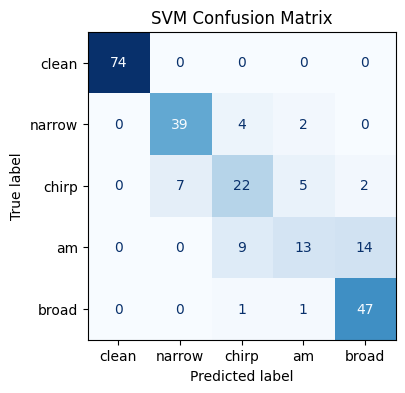

--- RandomForest ---
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        74
           1     0.8000    0.8889    0.8421        45
           2     0.6429    0.5000    0.5625        36
           3     0.6765    0.6389    0.6571        36
           4     0.8333    0.9184    0.8738        49

    accuracy                         0.8333       240
   macro avg     0.7905    0.7892    0.7871       240
weighted avg     0.8264    0.8333    0.8276       240



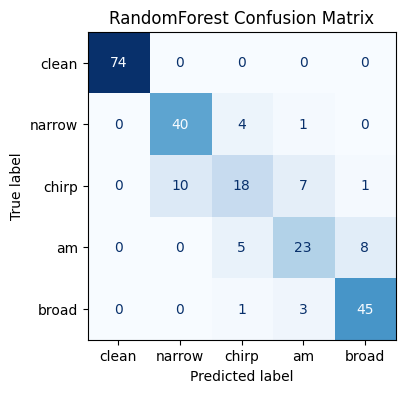

--- KNN ---
Accuracy: 0.8041666666666667
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        74
           1     0.7925    0.9333    0.8571        45
           2     0.5172    0.4167    0.4615        36
           3     0.6000    0.5000    0.5455        36
           4     0.8148    0.8980    0.8544        49

    accuracy                         0.8042       240
   macro avg     0.7449    0.7496    0.7437       240
weighted avg     0.7909    0.8042    0.7945       240



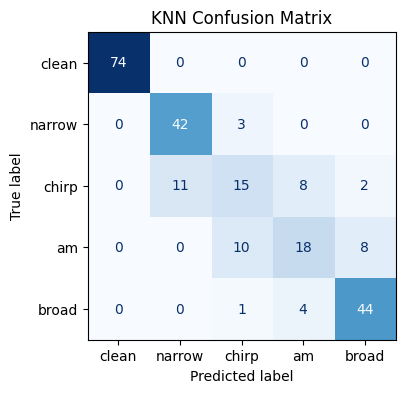

In [ ]:
# Display ML metrics & confusion matrices (after training in Cell 4)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# load test split (from earlier in notebook)
# X_test_s, y_test are available if you ran Cell 4 as-is.

for name in ['SVM','RandomForest','KNN']:
    obj = joblib.load(os.path.join(MODELS_DIR, f'{name}_model.pkl'))
    model = obj['model']; scaler = obj['scaler']
    # Note: for SVM/RF/KNN we saved same scaler; we already have X_test_s, y_test
    preds = model.predict(X_test_s)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds, digits=4))
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['clean','narrow','chirp','am','broad'])
    fig, ax = plt.subplots(figsize=(5,4))
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.show()


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       0.78      0.95      0.86        41
           2       1.00      1.00      1.00        43
           3       0.89      0.69      0.77        35
           4       1.00      0.98      0.99        51

    accuracy                           0.94       240
   macro avg       0.93      0.92      0.92       240
weighted avg       0.95      0.94      0.94       240



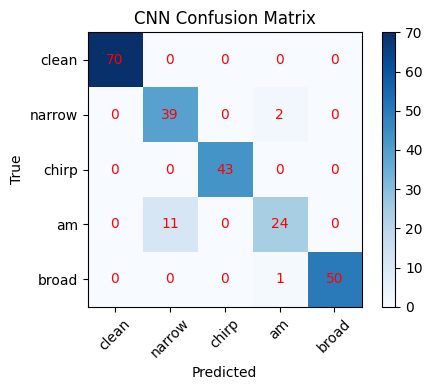

In [ ]:
# Evaluate CNN saved weights (last epoch)
cm_cnn, ys_cnn, ps_cnn = eval_torch_model(SimpleCNN(n_classes=5), os.path.join(MODELS_DIR, 'cnn_epoch8.pth'))
plot_cm(cm_cnn, 'CNN Confusion Matrix')
# Print validation accuracy and sample classification report already printed inside eval_torch_model


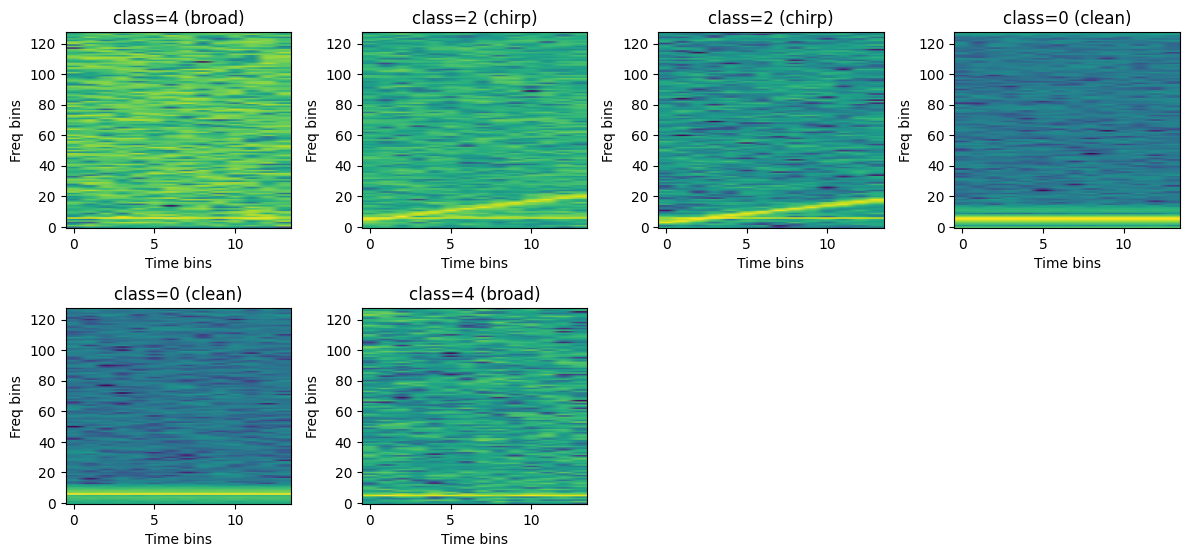

In [ ]:
# Show 6 spectrograms (two from each class if possible)
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv(os.path.join(PROCESSED_DIR,'features.csv'))
samples_per_class = {i:0 for i in range(5)}
plt.figure(figsize=(12,8))
plot_idx = 1
for idx, row in df.iterrows():
    label = int(row['label'])
    if samples_per_class[label] < 2:
        spec = np.load(os.path.join(spec_dir, row['filename']))
        plt.subplot(3,4,plot_idx)
        plt.imshow(spec, aspect='auto', origin='lower')
        plt.title(f'class={label} ({["clean","narrow","chirp","am","broad"][label]})')
        plt.xlabel('Time bins'); plt.ylabel('Freq bins')
        plot_idx += 1
        samples_per_class[label] += 1
    if plot_idx > 6: break
plt.tight_layout(); plt.show()


In [ ]:
import numpy as np
from scipy import signal
import joblib
import torch
import os

# =====================
# Load IQ sample
# =====================
sample_npz = np.load(os.path.join(DATA_DIR, 'iq_00010.npz'))
iq = sample_npz['iq']


# ============================================================
#  FEATURE EXTRACTION (MATCHES TRAINED SCALER: 3 FEATURES)
# ============================================================
def extract_features_for_ml(iq, fs=2000):
    # 1) Power
    power = np.mean(np.abs(iq)**2)

    # 2) Spectral centroid
    f, t, Sxx = signal.spectrogram(iq, fs=fs, nperseg=128, noverlap=64)
    mean_spec = np.mean(Sxx, axis=1)
    centroid = np.sum(f * mean_spec) / (np.sum(mean_spec) + 1e-9)

    # 3) Spectral bandwidth
    bandwidth = np.sqrt(np.sum(((f - centroid) ** 2) * mean_spec) /
                        (np.sum(mean_spec) + 1e-9))

    return np.array([power, centroid, bandwidth]).reshape(1, -1)


# ============================================================
#  ML PREDICTION (RF + SCALER IN SAME FILE)
# ============================================================

# Load RF model object (contains both model + scaler)
rf_obj = joblib.load(os.path.join(MODELS_DIR, "RandomForest_model.pkl"))

rf_model = rf_obj["model"]
scaler = rf_obj["scaler"]   # no need for scaler.pkl file

# Extract features
ml_feat = extract_features_for_ml(iq)

# Scale features
ml_feat_s = scaler.transform(ml_feat)

# Predict
pred_ml = rf_model.predict(ml_feat_s)
print("RF predicted class:", pred_ml[0])


# ============================================================
#  CNN PREDICTION
# ============================================================
def compute_spectrogram(iq, fs=2000, nperseg=128, noverlap=64):
    f, t, Sxx = signal.spectrogram(iq, fs=fs, nperseg=nperseg, noverlap=noverlap)
    return f, t, Sxx


# Prepare spectrogram
f, t, Sxx = compute_spectrogram(iq)
spec = (np.log10(Sxx + 1e-12)).astype("float32")
spec = (spec - spec.mean()) / (spec.std() + 1e-9)

# Convert to tensor
spec_tensor = torch.from_numpy(spec[np.newaxis, np.newaxis, ...]).to("cpu")

# Load CNN
cnn_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, "cnn_final.pth"), map_location="cpu"))
cnn_model.eval()

# Predict
with torch.no_grad():
    out = cnn_model(spec_tensor)
    pred_dl = out.argmax(dim=1).cpu().numpy()[0]

print("CNN predicted class:", pred_dl)


RF predicted class: 0
CNN predicted class: 4


/tmp/ipython-input-355578969.py:22: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Sxx = signal.spectrogram(iq, fs=fs, nperseg=128, noverlap=64)
/tmp/ipython-input-355578969.py:58: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Sxx = signal.spectrogram(iq, fs=fs, nperseg=nperseg, noverlap=noverlap)
